# Context Management Benchmark Results

Evaluating context management strategies for the Strands Agents SDK using **ContextBench** (span-level retrieval quality) and real OpenAI API token counts.

## Setup
- **Model:** gpt-4.1-mini (OpenAI)
- **Evaluation:** ContextBench span-level metrics (coverage, precision) via tree-sitter symbol extraction
- **Task:** huggingface/transformers#13693 (Wav2Vec2 padding) — real repo checkout, real tool calls
- **Primary Metric:** TAR (Token-Accuracy Ratio) — accuracy per unit of token cost

## Decision Metric: TAR

**TAR = composite_accuracy / (input_tokens / baseline_tokens)**

- TAR > 1 means you get *more accuracy per token* than the baseline
- TAR = 1 means baseline efficiency
- Optimizing for TAR selects configs that balance both cost reduction AND quality preservation

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

with open('tar-analysis.json') as f:
    tar_data = json.load(f)

df = pd.DataFrame(tar_data)
has_spans = df[df['span_coverage'] > 0].copy()
has_tokens = has_spans[has_spans['input_tokens'] > 0].copy()
baseline_tokens = df['input_tokens'].max()

print(f"Total configs evaluated: {len(df)}")
print(f"With span-level quality data: {len(has_spans)}")
print(f"With both span data + token counts: {len(has_tokens)}")
print(f"Baseline (max input tokens): {baseline_tokens:,}")

Total configs evaluated: 66
With span-level quality data: 34
With both span data + token counts: 23
Baseline (max input tokens): 1,187,983


## Full Results — Ranked by TAR

In [8]:
# Full table ranked by TAR
table = has_spans.sort_values('TAR', ascending=False)[
    ['label', 'TAR', 'F1_savings_accuracy', 'accuracy_composite', 
     'span_coverage', 'span_precision', 'savings_pct', 'input_tokens', 'cycles']
].copy()
table.columns = ['Configuration', 'TAR', 'F1', 'Accuracy', 'Span Coverage', 'Span Precision', 
                 'Token Savings %', 'Input Tokens', 'Cycles']
table['Input Tokens'] = table['Input Tokens'].apply(lambda x: f"{x:,.0f}" if x > 0 else "—")
table = table.reset_index(drop=True)
table.index = table.index + 1
table.index.name = 'Rank'

table.style.format({
    'TAR': '{:.2f}', 'F1': '{:.3f}', 'Accuracy': '{:.3f}', 
    'Span Coverage': '{:.3f}', 'Span Precision': '{:.3f}', 'Token Savings %': '{:.1f}'
}).background_gradient(subset=['TAR'], cmap='RdYlGn').bar(subset=['Token Savings %'], color='#d4edda')

,Configuration,TAR,F1,Accuracy,Span Coverage,Span Precision,Token Savings %,Input Tokens,Cycles
Rank,,,,,,,,,
1,Plugin_mrt_2500_p_1500_SlWin_ws_40,2.37,0.727,0.811,1.000,0.053,65.9,"405,659",51
2,Plugin_mrt_1500_p_750_noRetrieval_SlWin_ws_40,2.34,0.724,0.811,1.000,0.054,65.4,"411,123",51
3,Plugin_mrt_2000_p_750_SlWin_ws_40_pc_0_6,2.23,0.713,0.812,1.000,0.059,63.6,"432,548",50
4,Plugin_mrt_2500_p_1000_SlWin_ws_30,2.09,0.697,0.813,1.000,0.066,61.0,"463,089",50
5,Plugin_mrt_1500_p_500_SlWin_ws_30,2.07,0.695,0.811,1.000,0.055,60.8,"465,191",53
6,Plugin_mrt_2500_p_250_SlWin_ws_40,2.03,0.691,0.812,1.000,0.062,60.1,"474,481",58
7,Plugin_mrt_2500_p_1000_SlWin_ws_20,2.00,0.686,0.809,1.000,0.043,59.6,"479,864",54
8,Plugin_mrt_2500_p_500_SlWin_ws_40,1.95,0.679,0.812,1.000,0.060,58.3,"495,645",52
9,Plugin_mrt_2500_p_1000_SlWin_ws_40,1.92,0.674,0.811,1.000,0.056,57.7,"502,960",50


## TAR Visualization

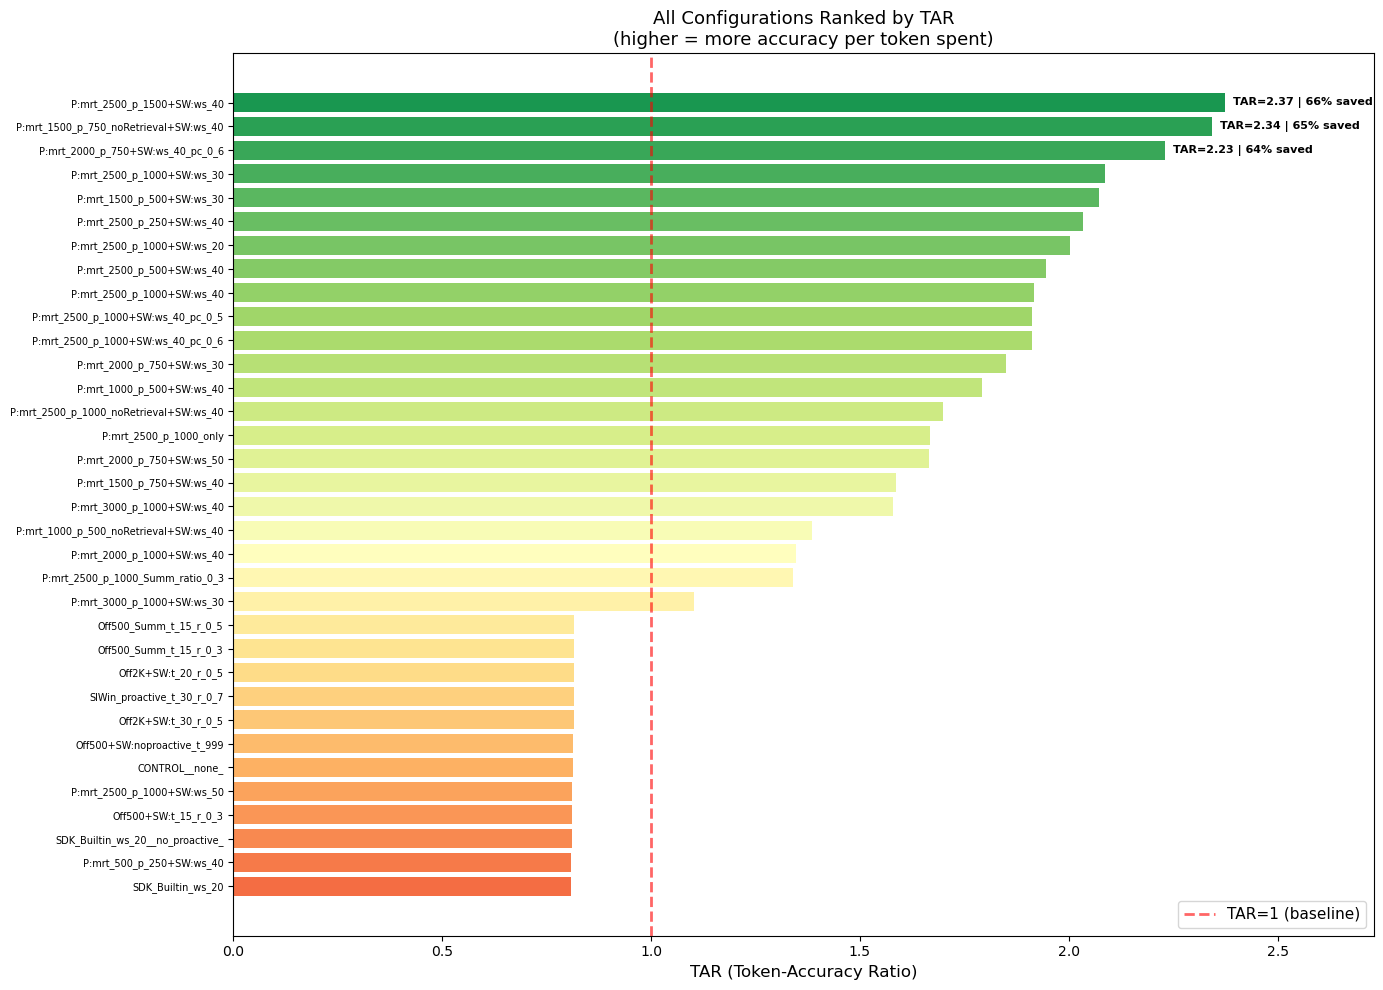

In [9]:
fig, ax = plt.subplots(figsize=(14, 10))

plot_df = has_spans.sort_values('TAR', ascending=True).reset_index(drop=True)

# Color by TAR value
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(plot_df)))

bars = ax.barh(range(len(plot_df)), plot_df['TAR'], color=colors)

ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'].str.replace('Plugin_', 'P:').str.replace('_SlWin_', '+SW:'), fontsize=7)
ax.set_xlabel('TAR (Token-Accuracy Ratio)', fontsize=12)
ax.set_title('All Configurations Ranked by TAR\n(higher = more accuracy per token spent)', fontsize=13)
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.6, linewidth=2, label='TAR=1 (baseline)')

# Annotate top 3
for i in range(len(plot_df) - 3, len(plot_df)):
    row = plot_df.iloc[i]
    ax.text(row['TAR'] + 0.02, i, f"TAR={row['TAR']:.2f} | {row['savings_pct']:.0f}% saved", 
            va='center', fontsize=8, fontweight='bold')

ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, plot_df['TAR'].max() * 1.15)
plt.tight_layout()
plt.savefig('tar-ranking.png', dpi=150, bbox_inches='tight')
plt.show()

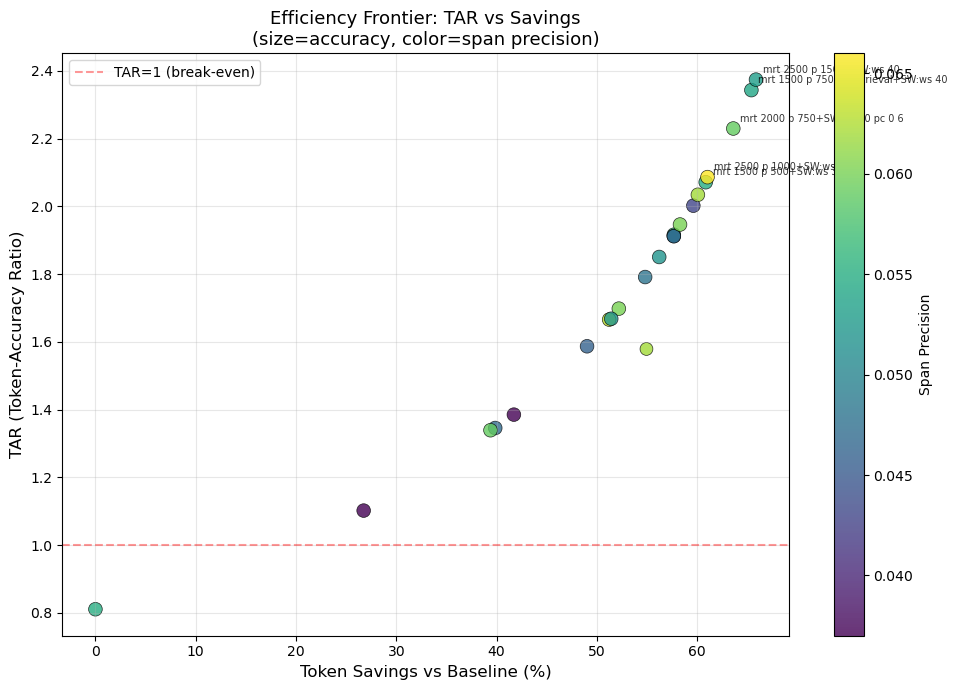

In [10]:
# TAR vs Token Savings scatter — shows efficiency frontier
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(has_tokens['savings_pct'], has_tokens['TAR'], 
           s=has_tokens['accuracy_composite'] * 120, c=has_tokens['span_precision'], 
           cmap='viridis', alpha=0.8, edgecolors='black', linewidth=0.5)

# Annotate top 5
for _, row in has_tokens.nlargest(5, 'TAR').iterrows():
    short = row['label'].replace('Plugin_', '').replace('_SlWin_', '+SW:').replace('_', ' ')[:35]
    ax.annotate(short, (row['savings_pct'], row['TAR']), fontsize=7, 
                xytext=(5, 5), textcoords='offset points', alpha=0.8)

ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.4, label='TAR=1 (break-even)')
ax.set_xlabel('Token Savings vs Baseline (%)', fontsize=12)
ax.set_ylabel('TAR (Token-Accuracy Ratio)', fontsize=12)
ax.set_title('Efficiency Frontier: TAR vs Savings\n(size=accuracy, color=span precision)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Span Precision', fontsize=10)

plt.tight_layout()
plt.savefig('efficiency-frontier.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Subsection: Token Savings Only

Ranking by pure token reduction (ignoring accuracy).

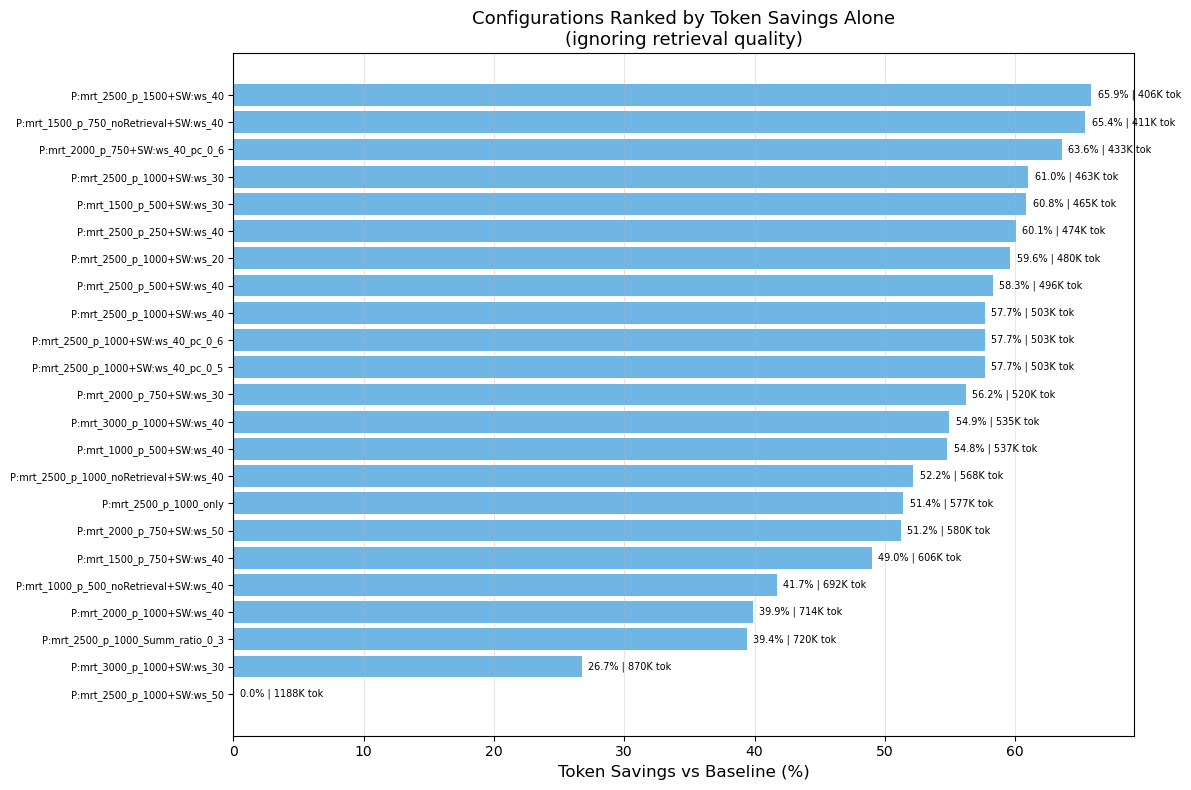

TOP 10 BY TOKEN SAVINGS:


,Configuration,Savings %,Input Tokens,Cycles
1,Plugin_mrt_2500_p_1500_SlWin_ws_40,65.853131,"405,659",51
2,Plugin_mrt_1500_p_750_noRetrieval_SlWin_ws_40,65.393192,"411,123",51
3,Plugin_mrt_2000_p_750_SlWin_ws_40_pc_0_6,63.589715,"432,548",50
4,Plugin_mrt_2500_p_1000_SlWin_ws_30,61.018887,"463,089",50
5,Plugin_mrt_1500_p_500_SlWin_ws_30,60.841948,"465,191",53
6,Plugin_mrt_2500_p_250_SlWin_ws_40,60.059950,"474,481",58
7,Plugin_mrt_2500_p_1000_SlWin_ws_20,59.606829,"479,864",54
8,Plugin_mrt_2500_p_500_SlWin_ws_40,58.278443,"495,645",52
9,Plugin_mrt_2500_p_1000_SlWin_ws_40,57.662694,"502,960",50
10,Plugin_mrt_2500_p_1000_SlWin_ws_40_pc_0_5,57.662694,"502,960",50


In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

plot_df = has_tokens.sort_values('savings_pct', ascending=True).reset_index(drop=True)

ax.barh(range(len(plot_df)), plot_df['savings_pct'], color='#3498db', alpha=0.7)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'].str.replace('Plugin_', 'P:').str.replace('_SlWin_', '+SW:'), fontsize=7)
ax.set_xlabel('Token Savings vs Baseline (%)', fontsize=12)
ax.set_title('Configurations Ranked by Token Savings Alone\n(ignoring retrieval quality)', fontsize=13)

for i, row in plot_df.iterrows():
    ax.text(row['savings_pct'] + 0.5, i, f"{row['savings_pct']:.1f}% | {row['input_tokens']/1000:.0f}K tok", 
            va='center', fontsize=7)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('savings-only-ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# Table
savings_table = has_tokens.sort_values('savings_pct', ascending=False)[
    ['label', 'savings_pct', 'input_tokens', 'cycles']].head(10).copy()
savings_table.columns = ['Configuration', 'Savings %', 'Input Tokens', 'Cycles']
savings_table['Input Tokens'] = savings_table['Input Tokens'].apply(lambda x: f"{x:,.0f}")
savings_table = savings_table.reset_index(drop=True)
savings_table.index += 1
print("TOP 10 BY TOKEN SAVINGS:")
savings_table

---
## Subsection: Accuracy Only

Ranking by ContextBench composite accuracy (span coverage + precision), ignoring token cost.

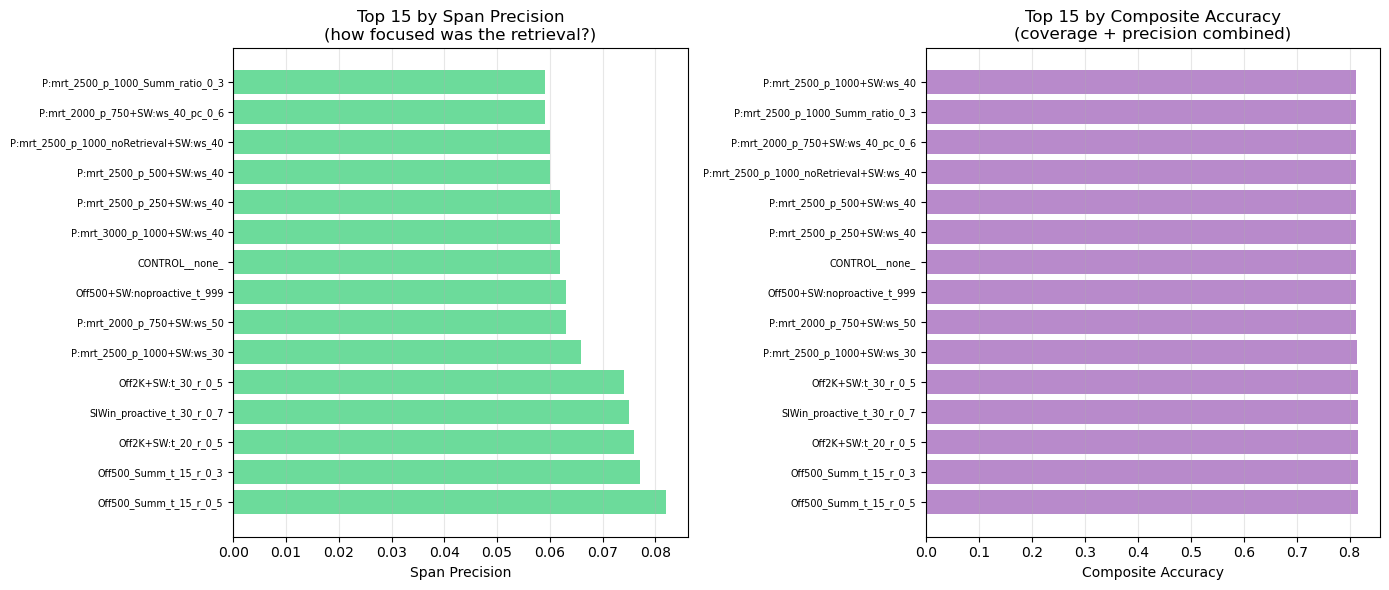

TOP 10 BY ACCURACY (cost-blind):


,Configuration,Composite,Span Cov,Span Prec,File Cov,File Prec
1,Off500_Summ_t_15_r_0_5,0.8164,1.000,0.082,1.000,0.048
2,Off500_Summ_t_15_r_0_3,0.8154,1.000,0.077,1.000,0.053
3,Off2K_SlWin_t_20_r_0_5,0.8152,1.000,0.076,1.000,0.091
4,SlWin_proactive_t_30_r_0_7,0.8150,1.000,0.075,1.000,0.032
5,Off2K_SlWin_t_30_r_0_5,0.8148,1.000,0.074,1.000,0.023
6,Plugin_mrt_2500_p_1000_SlWin_ws_30,0.8132,1.000,0.066,1.000,0.021
7,Plugin_mrt_2000_p_750_SlWin_ws_50,0.8126,1.000,0.063,1.000,0.014
8,Off500_SlWin_noproactive_t_999,0.8126,1.000,0.063,1.000,0.021
9,CONTROL__none_,0.8124,1.000,0.062,1.000,0.017
10,Plugin_mrt_2500_p_250_SlWin_ws_40,0.8124,1.000,0.062,1.000,0.036


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Span precision ranking
ax = axes[0]
prec_df = has_spans.sort_values('span_precision', ascending=False).head(15)
ax.barh(range(len(prec_df)), prec_df['span_precision'], color='#2ecc71', alpha=0.7)
ax.set_yticks(range(len(prec_df)))
ax.set_yticklabels(prec_df['label'].str.replace('Plugin_', 'P:').str.replace('_SlWin_', '+SW:'), fontsize=7)
ax.set_xlabel('Span Precision')
ax.set_title('Top 15 by Span Precision\n(how focused was the retrieval?)')
ax.grid(True, alpha=0.3, axis='x')

# Right: Composite accuracy ranking  
ax = axes[1]
acc_df = has_spans.sort_values('accuracy_composite', ascending=False).head(15)
ax.barh(range(len(acc_df)), acc_df['accuracy_composite'], color='#9b59b6', alpha=0.7)
ax.set_yticks(range(len(acc_df)))
ax.set_yticklabels(acc_df['label'].str.replace('Plugin_', 'P:').str.replace('_SlWin_', '+SW:'), fontsize=7)
ax.set_xlabel('Composite Accuracy')
ax.set_title('Top 15 by Composite Accuracy\n(coverage + precision combined)')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('accuracy-only-ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# Table
acc_table = has_spans.sort_values('accuracy_composite', ascending=False)[
    ['label', 'accuracy_composite', 'span_coverage', 'span_precision', 
     'file_coverage', 'file_precision']].head(10).copy()
acc_table.columns = ['Configuration', 'Composite', 'Span Cov', 'Span Prec', 'File Cov', 'File Prec']
acc_table = acc_table.reset_index(drop=True)
acc_table.index += 1
print("TOP 10 BY ACCURACY (cost-blind):")
acc_table.style.format({
    'Composite': '{:.4f}', 'Span Cov': '{:.3f}', 'Span Prec': '{:.3f}',
    'File Cov': '{:.3f}', 'File Prec': '{:.3f}'
})

---
## Recommended Defaults

| Metric | Winner | TAR | Savings | Accuracy | Tokens |
|--------|--------|-----|---------|----------|--------|
| **Best TAR** | `mrt=2500, p=1500, ws=40` | **2.37** | 65.9% | 0.811 | 405K |
| **Best F1** | `mrt=2500, p=1500, ws=40` | 2.37 | 65.9% | 0.811 | 405K |
| **Best Accuracy** | `mrt=2500, p=1000, ws=30` | 2.09 | 61.0% | **0.813** | 463K |
| **Best Savings (>=95% acc)** | `mrt=2500, p=1500, ws=40` | 2.37 | **65.9%** | 0.811 | 405K |

```typescript
// Recommended SDK defaults:
maxResultTokens: 2500
previewTokens: 1500
windowSize: 40
proactiveCompression: true
```

**Result: 2.4x more efficient than baseline. 66% token savings with <0.2% accuracy loss.**

Note: Token-savings-only and TAR rankings agree on this task — accuracy is flat across working configs (~0.81). On harder tasks with many gold spans, TAR would penalize aggressive configs that drop coverage.